# Machine Learning Principles and Concepts: Assignment 2025 - 2026

## Dataset description

This assignment must be conducted by using the `kc_house_data.csv` dataset. It is a single CSV (Comma Separated Values) file that contains prices for 21613 houses (samples). The CSV file has been uploaded to the e-learning platform along with this notebook.

The dataset contains 21 columns. The `price` column contains the target variable for training our regression models. The rest 20 columns represent other features which can be either numerical, or categorical.


## Task 1: Processing the dataset

In this task you will perform some simple pre-processing operations on the given data. There are two sub-tasks in this task. More specifically:

- Drop the columns `id`, `date`, and `zipcode`. The new dataset shape should be 21613 rows by 18 columns.
- The `price` column will be our target variable. After the removal of the 3 aforementioned columns (`id`, `date` and `zipcode`), the `price` column is now first. Move it to the end of the dataset (i.e. the `price` column should be the last one in the dataset).


In [1]:
import pandas as pd

# Load the data in a Pandas Dataframe
house_data = pd.read_csv("kc_house_data.csv", sep = ",")
print(house_data.head())

# DataFrame.drop(labels=None, *, axis=0, index=None, columns=None, level=None, inplace=False, errors='raise') wiht inplace=True in order to modify the dataframe
house_data.drop(columns = ["id", "date", "zipcode"], inplace = True)
print(house_data.head())

# DataFrame.shape returns (rows, columns) of the dataframe
print("New data shape:", house_data.shape)

# DataFrame.pop(item) where it returns the price column and drops it from house_data . Then add it as a new column in the dataframe which is appended in the end
price = house_data.pop("price")
house_data["price"] = price
print(house_data.head())

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

## Task 2: Feature engineering

The dataset contains both numerical and categorical features. There are five sub-tasks in this task. More specifically:


### 2.1. Dataset statistics

Report the minimum, maximum, and mean values for each numerical feature.


In [2]:
import numpy as np

# DataFrame.describe(percentiles=None, include=None, exclude=None) generates descriptive statistics. With np.number we keep only the numeric columns
# With .loc we specified the row we want to display
summary = house_data.describe(include = [np.number]).loc[["min", "max", "mean"]]
print("Min, Max and Mean values for numerical features:", summary, sep = "\n")

Min, Max and Mean values for numerical features:
       bedrooms  bathrooms   sqft_living      sqft_lot    floors  waterfront  \
min    0.000000   0.000000    290.000000  5.200000e+02  1.000000    0.000000   
max   33.000000   8.000000  13540.000000  1.651359e+06  3.500000    1.000000   
mean   3.370842   2.114757   2079.899736  1.510697e+04  1.494309    0.007542   

          view  condition      grade   sqft_above  sqft_basement     yr_built  \
min   0.000000    1.00000   1.000000   290.000000       0.000000  1900.000000   
max   4.000000    5.00000  13.000000  9410.000000    4820.000000  2015.000000   
mean  0.234303    3.40943   7.656873  1788.390691     291.509045  1971.005136   

      yr_renovated        lat        long  sqft_living15     sqft_lot15  \
min       0.000000  47.155900 -122.519000     399.000000     651.000000   
max    2015.000000  47.777600 -121.315000    6210.000000  871200.000000   
mean     84.402258  47.560053 -122.213896    1986.552492   12768.455652   

    

### 2.2. How many missing values do we have per column?

Count the number of rows that have missing values per column.

In [3]:
# Count missing values per column 
print("Missing values per column:", house_data.isna().sum(), sep = "\n")

Missing values per column:
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
price            0
dtype: int64


### 2.3 How many distinct values do we have per column?

Count the number of distinct values per column.

In [4]:
# DataFrame.nunique(axis=0, dropna=True) count number of distinct elements in specified axis where defaul is 0 for row-wise
print("The number of distinct values per column:", house_data.nunique(), sep = "\n")

The number of distinct values per column:
bedrooms           13
bathrooms          30
sqft_living      1038
sqft_lot         9782
floors              6
waterfront          2
view                5
condition           5
grade              12
sqft_above        946
sqft_basement     306
yr_built          116
yr_renovated       70
lat              5034
long              752
sqft_living15     777
sqft_lot15       8689
price            4028
dtype: int64


### 2.4. Correlation with the target variable (visual)

Study the correlation of each feature with the target variable. More specifically, you must create plots that illustrate the feature values against the target variable. These must be scatter plots similar to the ones that were presented in the notebook about Linear Regression.

Describe the general impression on how the monotony of an input variable is correlated to the monotony of the target variable (e.g. by increasing the value of this feature the price increases/decreases/is unaffected/is affected randomly, and so on).

This is what your figure/s must look like:


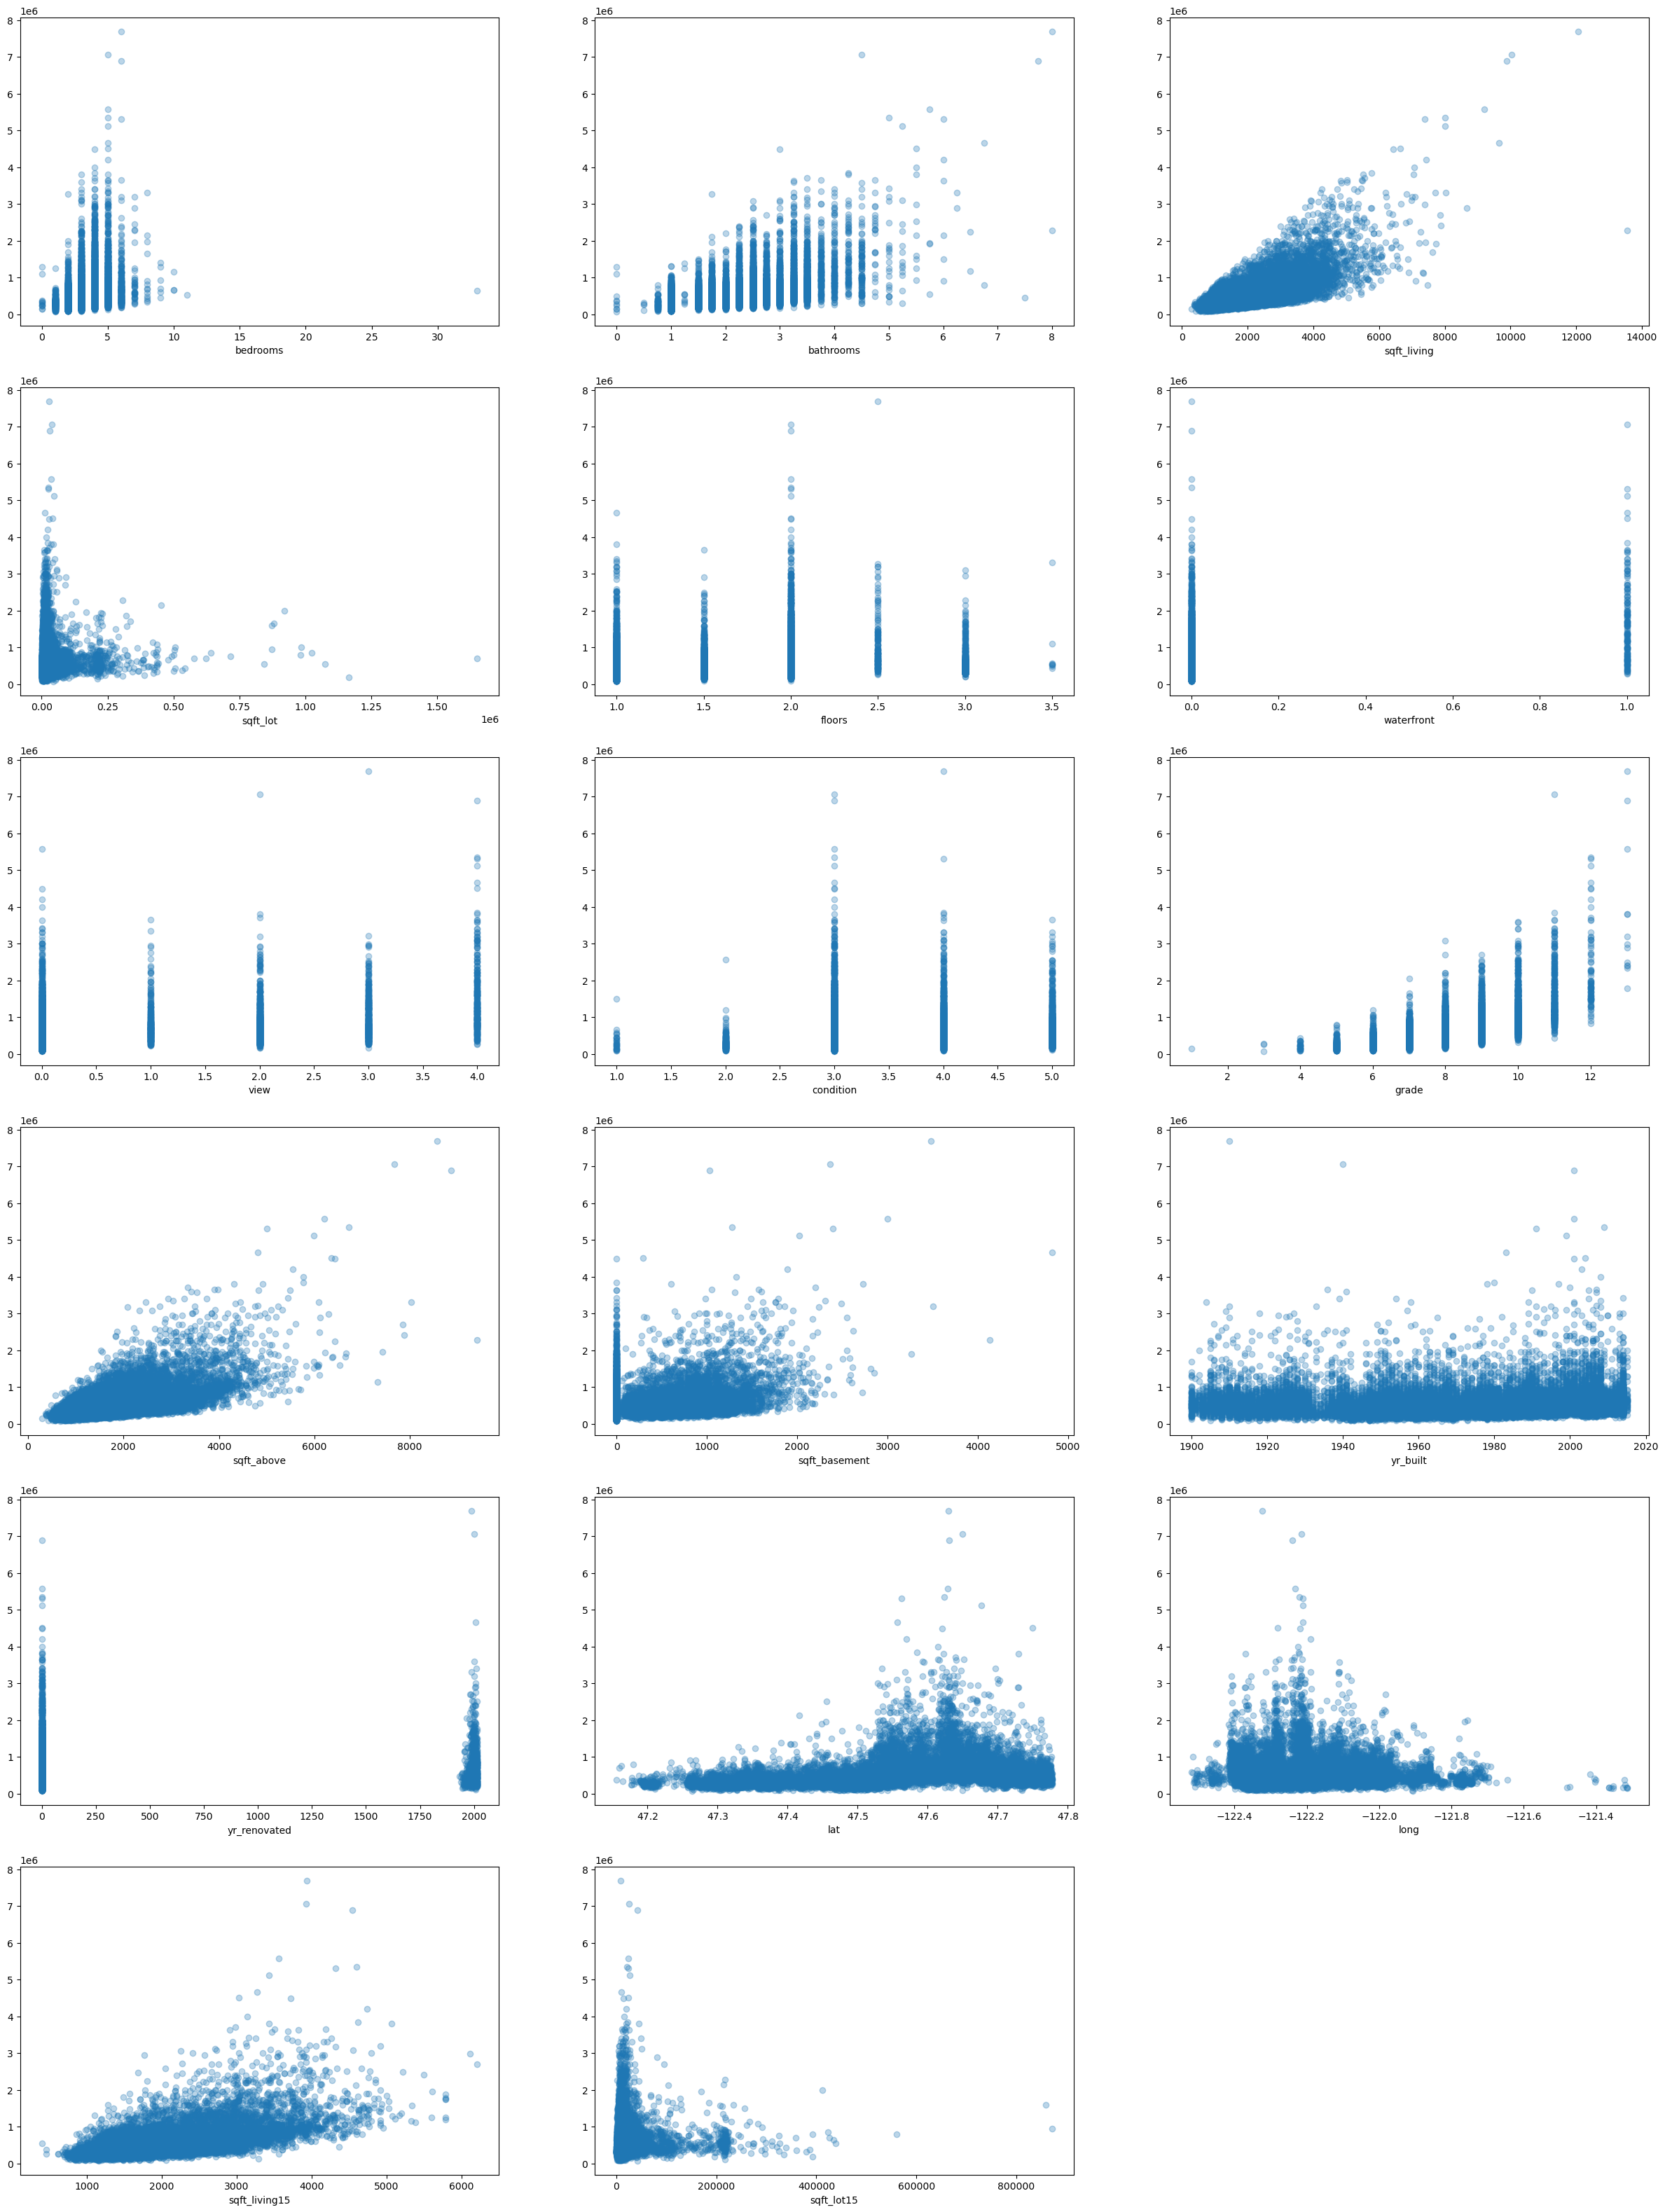

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (30, 40))

# Created a for loop in order to not repeat each subplot individually. Used .columns to get the column labels for the featuer values from the DataFrame
for i in range (1,18):
    ax = fig.add_subplot(6, 3, i) 
    ax.scatter(house_data.iloc[:,i - 1], house_data["price"], marker = 'o', alpha = 0.3)
    ax.set_xlabel(house_data.columns[i - 1])
    ax.set_label("price")
    

### 2.5 Managing the categorical features

Although all features seem to have numerical values, subsection 2.3 shows that several features receive only distinct values. For example, `view` and `condition` have only 5 distinct values.

In reality, we can either leave these features intact, drop them, or convert them to numerical ones. 
Here you will perform the following actions:

* Treat the following features as categorical ones: `view` and `condition`. Notice that `waterfront` receives binary values, so it is already encoded. Convert `view` and `condition` to numerical ones by applying one-hot-encoding. As mentioned in the class, in one-hot-encoding the first value of each encoded feature is not required. So to reduce dimensionality, remove this first value from each one-hot-encoded feature.
* Again, move the `price` column to the end of the dataset.

  **Hint:** If you are managing the data with Pandas dataframes, use the `get_dummies` method with `drop_first=True`.

After this process, the shape of the dataset must be 21613 rows $\times$ 24 columns.


In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Using ColumnTransformer to apply One-Hot-Encoding only to 'view' and 'condition' columns. Adding remainder='passthrough' ensures all other columns will remain unchanged 
c_transf = ColumnTransformer([ ('onehot', OneHotEncoder(), ['view','condition'])], remainder = 'passthrough')
c_transf.fit_transform(house_data).astype(float)

# Perform OHE on the DataFrame and droping the first column of the encoded features to reduce dimensionality. Also use dtype=int to force the output to be 0 and 1 instead of True and False
house_data_ohe = pd.get_dummies(house_data, columns = ['view', 'condition'], drop_first = True, dtype = int)

# DataFrame.shape returns (rows, columns) of the dataframe
print("New data shape:", house_data_ohe.shape)

# DataFrame.pop(item) where it returns the price column and drops it from house_data_ohe . Then add it as a new column in the dataframe which is appended in the end
price = house_data_ohe.pop("price")
house_data_ohe["price"] = price
print("House data after applying one-hot-encoding on View and Condition features:\n", house_data_ohe.head())

New data shape: (21613, 24)
House data after applying one-hot-encoding on View and Condition features:
    bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  grade  \
0         3       1.00         1180      5650     1.0           0      7   
1         3       2.25         2570      7242     2.0           0      7   
2         2       1.00          770     10000     1.0           0      6   
3         4       3.00         1960      5000     1.0           0      7   
4         3       2.00         1680      8080     1.0           0      8   

   sqft_above  sqft_basement  yr_built  ...  sqft_lot15  view_1  view_2  \
0        1180              0      1955  ...        5650       0       0   
1        2170            400      1951  ...        7639       0       0   
2         770              0      1933  ...        8062       0       0   
3        1050            910      1965  ...        5000       0       0   
4        1680              0      1987  ...        7503       0 

### 2.6 Correlation with the target variables (numerical)

This is an important process, as it indicates the features that are strongly correlated to the target variable. There are several ways of estimating this correlation.

* Compute the Pearson coefficient that quantifies the pairwise correlations of the dataset columns (including the target variable).
* Identify the 8 features that have the strongest correlation with the target variable.
* Create a heatmap of the pairwise feature correlations like the following one.

**Important:** Please remove the sample image `heatmap.png` from your submission.

**Hint:** use the `seaborn` library.

The 8 features that have the strongest correlation with the target variable are:
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
Name: price, dtype: float64


<Axes: >

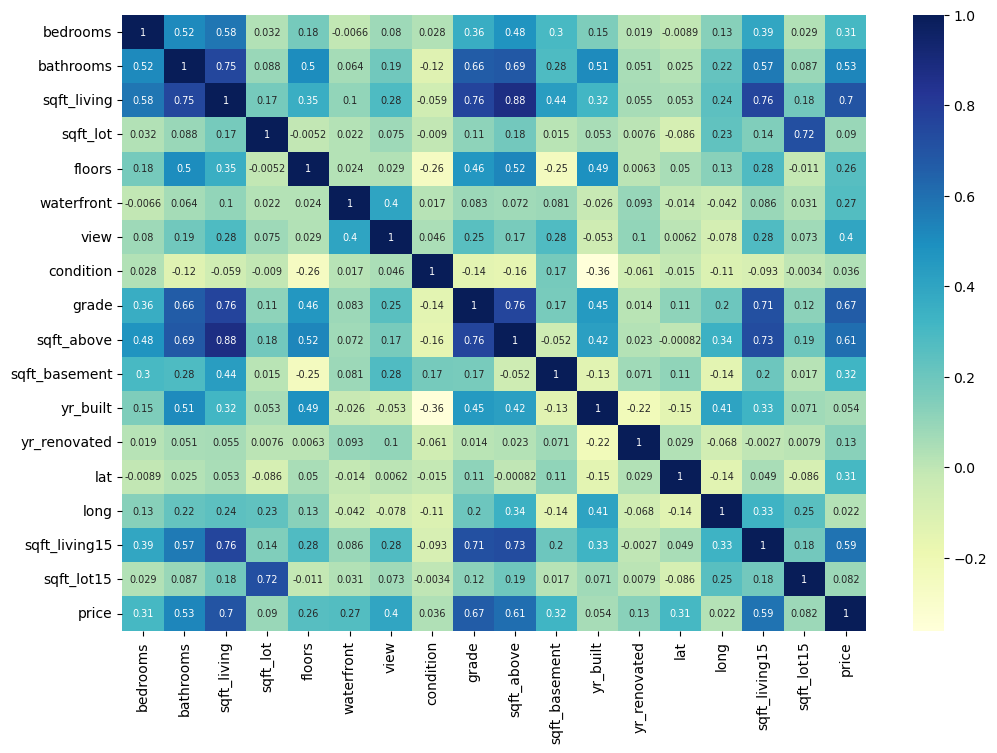

In [7]:
import seaborn as sns

plt.figure(figsize = (12, 8))

ax = fig.add_subplot(6, 3, i)
# DataFrame.corr(method = 'pearson') computes the Pearson coefficient
pear_coef = house_data.corr('pearson')

# sort_values() orders the data by the 'price' column 
# abs() returns the absolute values in order to get the 8 highest values (because the coefficient can be either negative or positive)
# iloc[1:,-1] returns only the column 'price' 
# head(8) returns the 8 features with the highest values 
top_feat = pear_coef.abs().sort_values(by = 'price', ascending = False).iloc[1:,-1].head(8)

print("The 8 features that have the strongest correlation with the target variable are:\n", top_feat, sep = '')

# sns.heatmap() generates the heatmap using Seaborn 
#cmap='YlGnBu' sets the color gradient from yellow to blue
#annot=True displays the coefficient values 
# annot_kws={"size":7} changes the font size
sns.heatmap(pear_coef, cmap = "YlGnBu", annot = True, annot_kws = {"size":7})


# Task 3: Create a model to predict the target variable

This is a typical Regression problem. You will experiment with the following scikit-learn algorithms:

* `LinearRegression`: Ordinary Least Squares Linear Regression.
* `Ridge`: Linear least squares with L2 regularization.
* `Lasso`: Linear Model trained with L1 prior as regularizer (aka the Lasso).
* `DecisionTreeRegressor`: Decision Tree for Regression problems.
* `RandomForestRegressor`: Random Forest for Regression problems.

In addition:
* You will apply 5-fold cross validation.
* You will run the experiments for three different random states: 0, 1, and 42.

Train the models by studying the effect of various hyper-parameters. Create a comparative table of Mean Squared Error, Mean Absolute Error, and R2 score for each algorithm. You must also present the results using bar plots (see the examples below).

**Note 1**: **The table will contain the mean values over all random states and all folds.** In other words, for each model you will first compute the mean value over all 5 folds; three mean values (one for each random state) per moel will derive. Then, you will present the mean of these mean values (over all three random states).

**Note 2:** You will report only the **best-performing results** for each model setting. However, you must mention which settings (i.e. hyperparameters) you tried.

For example: *"We tried Decision Tree Regressor with max_depth=2, 3, 4, 5,... and we got the best results for max_depth=4. The results are..."*


In [8]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

# Define the features and the target variable
X = house_data.drop(columns = ["price"])
Y = house_data["price"]

# Dictionary for the metrics of cross validation
scorers = { 'mean_squared_error': make_scorer(mean_squared_error), 'mean_absolute_error': make_scorer(mean_absolute_error), 'r2_score': make_scorer(r2_score)}

In [9]:
mse = []
mae = []
r2 = []

# Defining the list of regression models to evalue with the hyper-parameter options for the best results.
models = [LinearRegression(), Ridge(alpha = 1), Lasso(alpha = 1, tol = 0.1), DecisionTreeRegressor(max_depth = 6), RandomForestRegressor(n_estimators = 100, max_depth = 6)]

# for loop through each model
for i in models:
    mse_temp = []
    mae_temp = []
    r2_temp = []

# Iterate over the different random states for the training data
    for j in [0, 1, 42]:

# Splitting the data 20% for testing and 80% used for training (cross validation)
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = j)

# Perform 5-fold cross validation for only the training set
        cv_results = cross_validate(i, X_train, Y_train, cv = 5 , scoring = scorers, return_train_score = True)

# Store the mean scores for current random state (average of the 5 folds)
        mse_temp.append(cv_results['test_mean_squared_error'].mean())
        mae_temp.append(cv_results['test_mean_absolute_error'].mean())
        r2_temp.append(cv_results['test_r2_score'].mean()) 
        ;
        
# Calculating and storing the overall average across the 3 random states from the current model
# MSE, MAE, R2 are Numpy data types so we use np.mean() to get average out of the 3 mean values 
    mse.append(np.mean(mse_temp).item())
    mae.append(np.mean(mae_temp).item()) 
    r2.append(np.mean(r2_temp).item())
    ;

### Best performing results
**Ridge:** We performed hyperparameter tuning by testing alpha = 0.01, 0.1, 1, 10, 100. The model achieved optimal performance with **alpha = 1**.   
<br>
**Lasso:** We performed hyperparameter tuning by testing alpha = 0.01, 0.1, 1, 10, 100 and tolerance = 0.1. The model achieved optimal performance with **alpha = 1** and **tol = 0.1**.    
<br>
**Decision Tree:** We performed hyperparameter tuning by testing max_depth = 2, 4, 6, 8, 10. The model achieved optimal performance with **max_depth = 6**.    
<br>
**Random Forest:** We performed hyperparameter tuning by testing max_depth = 2, 4, 6, 8, 10 and n_estimators = 50, 100, 200. The model achieved optimal performance with **n_estimators = 100** and **max_depth = 6**.  

In [10]:
# Creating a dataframe of the results
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Decision Tree Regressor", "Random Forest Regressor"],
    "MSE": mse,
    "MAE": mae,
    "R2": r2
})
print("The best performing results:\n", results)

The best performing results:
                      Model           MSE            MAE        R2
0        Linear Regression  4.021251e+10  125885.347769  0.694867
1                    Ridge  4.021229e+10  125871.805288  0.694871
2                    Lasso  4.021250e+10  125884.618658  0.694867
3  Decision Tree Regressor  3.492116e+10  106629.282308  0.734248
4  Random Forest Regressor  2.639293e+10   94988.828943  0.799609


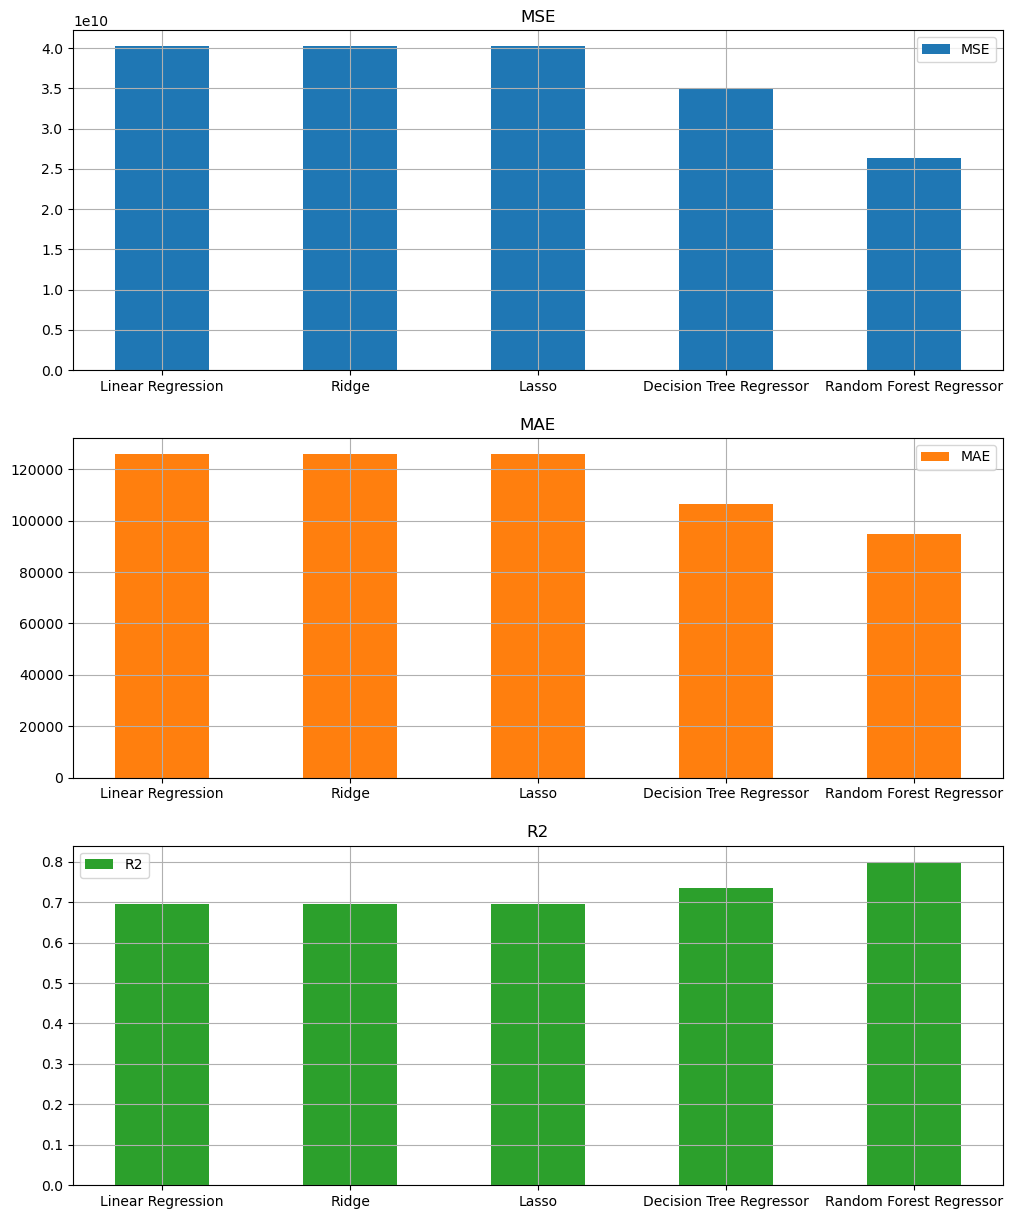

In [11]:
fig = plt.figure(figsize = (12, 15))

# Creating bar plot to compare the results
colors = ["tab:blue", "tab:orange", "tab:green"]
for i in range (1,4):
    ax = fig.add_subplot(3, 1, i) 
    ax.bar(results["Model"], results.iloc[:, i], width = 0.5, color = colors[i-1]) 
    ax.grid()

# Put on brackets in order to be a list with one item
    ax.legend([results.columns[i]])
    ax.set_title(results.columns[i])

# Task 4: Normalization

Apply min-max normalization to the data and repeat all the experiments **by using the same hyper-parameters for the models**. Again, report the values of Mean Squared Error, Mean Absolute Error, and R2 score.

Compare the performance of the models and discuss your conclusions. How do the models compare when they operate on standardized and non-standardized data?

In [12]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

mse_norm = []
mae_norm = []
r2_norm = []
for i in models:   
    mse_temp = []
    mae_temp = []
    r2_temp = []
    for j in [0, 1, 42]:
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = j)

# Pipeline() creating a pipeline to ensure the custom scaler is fitted only on the training set during cross validation
# MinMaxScaler() to perform min-max normalization
        pipe = Pipeline([('scaler', MinMaxScaler()), ('model', i)])
        
        cv_results = cross_validate(pipe, X_train, Y_train, cv = 5 , scoring = scorers, return_train_score = True)
       
        mse_temp.append(cv_results['test_mean_squared_error'].mean())
        mae_temp.append(cv_results['test_mean_absolute_error'].mean())
        r2_temp.append(cv_results['test_r2_score'].mean()) 
        ;
    mse_norm.append(np.mean(mse_temp).item())
    mae_norm.append(np.mean(mae_temp).item()) 
    r2_norm.append(np.mean(r2_temp).item())
    ;

results_norm = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Decision Tree Regressor", "Random Forest Regressor"],
    "Normalized MSE": mse_norm,
    "Normalized MAE": mae_norm,
    "Normalized R2": r2_norm
})
print(results_norm)

                     Model  Normalized MSE  Normalized MAE  Normalized R2
0        Linear Regression    4.021251e+10   125885.347769       0.694867
1                    Ridge    4.022761e+10   125678.340855       0.694811
2                    Lasso    4.021281e+10   125885.152992       0.694864
3  Decision Tree Regressor    3.485674e+10   106672.957229       0.734164
4  Random Forest Regressor    2.632953e+10    94950.727205       0.800076


### Comparing the results
Comparing the performance of the models we conlcude that the **Random Forest Regressor** is the clear winner. It achieved the lowest Error in both MSE and MAE metrics and the highest accuracy with an $R^2$ score of nearly 0.80. This indicates that the model explains approximately **80%** of the variance in the target variable (Price). It **outperforms** the Decision Tree, with a 0.73 score and all the Linear models (Linear Regression, Ridge, Lasso) wich reached a score  of 0.69 regardless of the data scaling. 
### Standardization effect
Standardization did **not improve the performance** of the linear models, it had little to no effect on the quality metrics. The tree based models showed also **no meaningful difference** in performance, but this is expected as tree algorithms rely on splits rather than distances and weighted sums. Finally, the fact that the Random Forest consistently outperformed the linear models (regardless of scaling) confirms that the relationship between the features and the target is non-linear, making the **tree-based approach the superior choice** for this dataset.

# Task 5: Dimensionality Reduction

In this task you will study the effect of dimensionality reduction in the performance of our regression models. More specifically, you will create a **new target space with 10 dimensions** by applying Principle Component Analysis (PCA) **on the standardized data**.

Discuss the results.


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

mse_pca = []
mae_pca = []
r2_pca = []
for i in models:   
    mse_temp = []
    mae_temp = []
    r2_temp = []
    for j in [0, 1, 42]:
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = j)

# StandardScaler() to standardize the data. 
# PCA(n_components = 10) to perform principal component analysis on the standardized data n=10 means reducing feature space to 10 dimensions.
        pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components = 10)), ('model', i)])
        
        cv_results = cross_validate(pipe, X_train, Y_train, cv = 5 , scoring = scorers, return_train_score = True)
       
        mse_temp.append(cv_results['test_mean_squared_error'].mean())
        mae_temp.append(cv_results['test_mean_absolute_error'].mean())
        r2_temp.append(cv_results['test_r2_score'].mean()) 
        ;
    mse_pca.append(np.mean(mse_temp).item())
    mae_pca.append(np.mean(mae_temp).item()) 
    r2_pca.append(np.mean(r2_temp).item())
    ;

results_pca = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Decision Tree Regressor", "Random Forest Regressor"],
    "PCA MSE": mse_pca,
    "PCA MAE": mae_pca,
    "PCA R2": r2_pca
})
print(results_pca)

                     Model       PCA MSE        PCA MAE    PCA R2
0        Linear Regression  4.303336e+10  128945.959938  0.673743
1                    Ridge  4.303335e+10  128944.452294  0.673743
2                    Lasso  4.303336e+10  128945.662522  0.673743
3  Decision Tree Regressor  4.464359e+10  123849.689547  0.659634
4  Random Forest Regressor  3.465235e+10  109884.451080  0.735677


### Comparing the results
The lower performance with PCA indicates that reducing the feature space from 18 to 10 dimensions resulted in **losing important information** that was necessary to predict the house prices accurately. The relationship between features and target variable is complex and the 10 components did not perform well. While the **linear models remained relatively stable**, the **tree based** models suffered a more **significant drop**. The tree based models performed best on the original data because they could find specific patterns between individual features (for example size and condition). When PCA combined these features together those patterns were lost and accuracy dropped.